<a href="https://colab.research.google.com/github/NyssaRomana/IDCamp-Dicoding/blob/main/DeepLearningSubmissionpynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Sentimen Ulasan Aplikasi Shopee di Google Play Store Menggunakan Deep Learning

## Deskripsi
Proyek ini bertujuan untuk melakukan analisis sentimen terhadap ulasan pengguna aplikasi Shopee di Google Play Store. Model deep learning digunakan untuk mengklasifikasikan sentimen menjadi tiga kategori: positif, netral, dan negatif.

## Dataset
Dataset diperoleh melalui proses scraping menggunakan Python dari Google Play Store dengan jumlah data lebih dari 10.000 ulasan.

## Metodologi
- Scraping data
- Preprocessing teks
- Ekstraksi fitur
- Pelatihan model deep learning (LSTM, GRU, BiLSTM)
- Evaluasi model
- Inference

In [135]:
# Install library untuk scraping Google Play Store
!pip install google-play-scraper

In [203]:
# Mengimpor pustaka google_play_scraper untuk mengakses ulasan dan informasi aplikasi dari Google Play Store.
from google_play_scraper import app, reviews, Sort, reviews_all

In [204]:
# Library untuk manipulasi data
import pandas as pd
pd.options.mode.chained_assignment = None

import numpy as np
seed = 0
np.random.seed(seed)

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Utility
import datetime as dt
import re
import string

# NLP
import nltk
nltk.download('punkt')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Install dan import Sastrawi
!pip install Sastrawi --quiet
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Visualisasi teks
from wordcloud import WordCloud

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Scraping Dataset

Pada proyek ini, dilakukan analisis sentimen terhadap ulasan pengguna aplikasi **Shopee** yang diambil dari Google Play Store. Ulasan pengguna merupakan sumber informasi penting yang mencerminkan pengalaman, kepuasan, serta permasalahan yang dihadapi selama menggunakan aplikasi.

Analisis sentimen bertujuan untuk mengklasifikasikan ulasan pengguna ke dalam tiga kategori, yaitu **positif, netral, dan negatif**. Dengan memanfaatkan teknik pemrosesan teks (Natural Language Processing) dan algoritma deep learning, model akan dilatih untuk memahami pola bahasa yang digunakan dalam ulasan.

Dataset diperoleh melalui proses scraping menggunakan Python, sehingga mencerminkan data aktual dari pengguna. Hasil analisis ini diharapkan dapat memberikan insight bagi pengembang aplikasi dalam meningkatkan kualitas layanan dan pengalaman pengguna.

In [205]:
# Fungsi untuk mengambil review secara bertahap (pagination)
def get_reviews(app_id, max_reviews=12000):
    review_list = []
    continuation_token = None

    while True:
        result, continuation_token = reviews(
            app_id,
            lang='id',
            country='id',
            sort=Sort.MOST_RELEVANT,
            count=200,
            continuation_token=continuation_token
        )

        for item in result:
            review_list.append({
                "author": item.get('userName'),
                "comment": item.get('content'),
                "rating": item.get('score'),
                "published_at": item.get('at'),
                "likes": item.get('thumbsUpCount', 0)
            })

            if len(review_list) >= max_reviews:
                return review_list

        if continuation_token is None:
            break

    return review_list

In [206]:
# Mengambil ulasan dari aplikasi Shopee
scrapreview = get_reviews('com.shopee.id', max_reviews=12000)

len(scrapreview)

print("Jumlah review berhasil diambil:", len(scrapreview))

Jumlah review berhasil diambil: 12000


In [207]:
df = pd.DataFrame(scrapreview)
df.to_csv("shopee_reviews.csv", index=False)

df.head()

,author,comment,rating,published_at,likes
0,misterius_,"Asli keamanannya bagus, aman juga lancar semua terkombinasi menjadi 1,performanya baik, bebas iklan, bug ataupun lemot, lancar jaya ketika dijalankan & membuka semua fitur2nya. Namun disayangkan sering ketika di pake terkadang agak"" susah membukanya pas saat koneksi lagi jelek / tidak stabil, terkadang loadingnya lambat sekali & cuma berputar aja.. mungkin cuman hal seperti itu yang biasa terjadi di apps ini dan aplikaainya sudah berjalan dengan baik, aplnya berfungsi sesuai keinginan -Adit baun",5,2026-03-03 12:39:10,5
1,Nailah Rahmaa,"Aplikasinya bagus, mudah dimengerti. Tapi bisa ga kalau bikin iklan di website/tempat lain tuh ga otomatis masuk ke aplikasinya? kek clickbait bgt bikin risih. Kalau mau bikin iklan tuh unjukin barang barang bagusnya bukan malah maksa user masuk ke aplikasi.",2,2026-03-16 01:12:19,1
2,Pipi Papi,"Top,Saya sangat suka belanja disini selain banyak voucher belanja juga ada gratis ongkir sangat memuaskan. tapi tidak dengan ekspedisi SPX nya tolonglah shopee lebih di peringatkan lagi kepada ekspedisinya selain sekarang terlalu lama barang datangnya, Paket saya juga sering hilang. Nunggu pengirimannya datang, sekarang bisa 10 harian dan kadang ada yang lebih ke daerah saya, dan tiba-tiba paketnya hilang itu sangat membuat kecewa terlebih tidak sekali paketnya hilang.",5,2026-03-10 07:31:47,3
3,Misaki Yuki,"koneksinya padahal bagus tapi susah banget buat masuk aplikasi sama lelet banget sedangkan di aplikasi lain berjalan normal, setelah saya cek sistem dan ruang penyimpanannya pun bagus hp saya normal semua cuman 1 aplikasi ini yg susah untuk di buka dan kinerja lambat, padahal semuanya aman, apapun solusinya intinya harus di tangani masalahnya!.",5,2026-03-06 03:37:59,6
4,el rarnjn,"Saya cukup terganggu dengan iklan Shopee yang sering muncul saat saya menggunakan aplikasi lain. Masalahnya, kadang iklan tersebut terbuka sendiri dan langsung mengarahkan ke aplikasi Shopee padahal saya tidak menekannya. Selain itu, tombol tutup (X) pada iklannya juga cukup sulit ditekan sehingga terasa sangat mengganggu pengalaman menggunakan ponsel. Saya harap pihak Shopee bisa memperbaiki sistem iklannya agar tidak terbuka sendiri dan tombol tutupnya lebih mudah digunakan. Terima kasih.",1,2026-03-07 00:14:38,5


In [208]:
print("Jumlah data:", len(df))

print("\nDistribusi Rating:")
print(df['rating'].value_counts().sort_index())

print("\nPersentase Rating:")
print(df['rating'].value_counts(normalize=True).sort_index() * 100)

Jumlah data: 12000

Distribusi Rating:
rating
1    4322
2     995
3     990
4     769
5    4924
Name: count, dtype: int64

Persentase Rating:
rating
1    36.016667
2     8.291667
3     8.250000
4     6.408333
5    41.033333
Name: proportion, dtype: float64


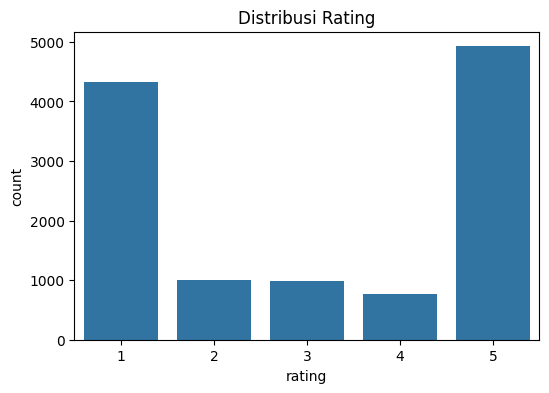

In [209]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=df)
plt.title('Distribusi Rating')
plt.show()

# Loading Dataset

Pada tahap ini, data hasil scraping yang telah diperoleh akan diubah ke dalam bentuk DataFrame menggunakan pustaka pandas. Struktur data ini memudahkan proses analisis dan pengolahan data pada tahap selanjutnya.

Dataset yang digunakan berisi informasi seperti:
- Nama pengguna
- Ulasan (teks)
- Rating
- Tanggal publikasi
- Jumlah likes

Selanjutnya, data akan ditampilkan untuk memastikan bahwa proses scraping telah berhasil dilakukan.

In [211]:
# Menampilkan jumlah baris dan kolom
print("Shape dataset:", df.shape)

# Menampilkan 5 data teratas
df.head()

# Menyimpan dataset ke file CSV
df.to_csv('shopee_reviews.csv', index=False)

Shape dataset: (12000, 5)


In [213]:
print("Jumlah ulasan:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

print("\nNama kolom:")
print(df.columns)

Jumlah ulasan: 12000
Jumlah kolom: 5

Nama kolom:
Index(['author', 'comment', 'rating', 'published_at', 'likes'], dtype='object')


In [214]:
# Menampilkan lima baris pertama dari dataset
df.head()

,author,comment,rating,published_at,likes
0,misterius_,"Asli keamanannya bagus, aman juga lancar semua terkombinasi menjadi 1,performanya baik, bebas iklan, bug ataupun lemot, lancar jaya ketika dijalankan & membuka semua fitur2nya. Namun disayangkan sering ketika di pake terkadang agak"" susah membukanya pas saat koneksi lagi jelek / tidak stabil, terkadang loadingnya lambat sekali & cuma berputar aja.. mungkin cuman hal seperti itu yang biasa terjadi di apps ini dan aplikaainya sudah berjalan dengan baik, aplnya berfungsi sesuai keinginan -Adit baun",5,2026-03-03 12:39:10,5
1,Nailah Rahmaa,"Aplikasinya bagus, mudah dimengerti. Tapi bisa ga kalau bikin iklan di website/tempat lain tuh ga otomatis masuk ke aplikasinya? kek clickbait bgt bikin risih. Kalau mau bikin iklan tuh unjukin barang barang bagusnya bukan malah maksa user masuk ke aplikasi.",2,2026-03-16 01:12:19,1
2,Pipi Papi,"Top,Saya sangat suka belanja disini selain banyak voucher belanja juga ada gratis ongkir sangat memuaskan. tapi tidak dengan ekspedisi SPX nya tolonglah shopee lebih di peringatkan lagi kepada ekspedisinya selain sekarang terlalu lama barang datangnya, Paket saya juga sering hilang. Nunggu pengirimannya datang, sekarang bisa 10 harian dan kadang ada yang lebih ke daerah saya, dan tiba-tiba paketnya hilang itu sangat membuat kecewa terlebih tidak sekali paketnya hilang.",5,2026-03-10 07:31:47,3
3,Misaki Yuki,"koneksinya padahal bagus tapi susah banget buat masuk aplikasi sama lelet banget sedangkan di aplikasi lain berjalan normal, setelah saya cek sistem dan ruang penyimpanannya pun bagus hp saya normal semua cuman 1 aplikasi ini yg susah untuk di buka dan kinerja lambat, padahal semuanya aman, apapun solusinya intinya harus di tangani masalahnya!.",5,2026-03-06 03:37:59,6
4,el rarnjn,"Saya cukup terganggu dengan iklan Shopee yang sering muncul saat saya menggunakan aplikasi lain. Masalahnya, kadang iklan tersebut terbuka sendiri dan langsung mengarahkan ke aplikasi Shopee padahal saya tidak menekannya. Selain itu, tombol tutup (X) pada iklannya juga cukup sulit ditekan sehingga terasa sangat mengganggu pengalaman menggunakan ponsel. Saya harap pihak Shopee bisa memperbaiki sistem iklannya agar tidak terbuka sendiri dan tombol tutupnya lebih mudah digunakan. Terima kasih.",1,2026-03-07 00:14:38,5


Untuk memahami struktur data yang telah diperoleh, ditampilkan lima baris pertama dari dataset. Hal ini bertujuan untuk memastikan bahwa data hasil scraping telah berhasil dimuat dengan benar dan memiliki format yang sesuai.

In [216]:
# Informasi dataset
df.info()

# Cek missing value
print("\nMissing values:")
print(df.isnull().sum())

print("\nPersentase missing:")
print((df.isnull().sum() / len(df)) * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   author        12000 non-null  object        
 1   comment       12000 non-null  object        
 2   rating        12000 non-null  int64         
 3   published_at  12000 non-null  datetime64[ns]
 4   likes         12000 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 468.9+ KB

Missing values:
author          0
comment         0
rating          0
published_at    0
likes           0
dtype: int64

Persentase missing:
author          0.0
comment         0.0
rating          0.0
published_at    0.0
likes           0.0
dtype: float64


Berdasarkan hasil pengecekan menggunakan fungsi `info()`, dataset memiliki total 12.000 data dengan 5 kolom, yaitu author, comment, rating, published_at, dan likes.

Tidak terdapat missing value pada seluruh kolom, sehingga data dapat langsung digunakan untuk tahap preprocessing tanpa perlu penanganan data kosong.


In [219]:
duplicate_count = df.duplicated(subset='comment').sum()
print("Jumlah duplikat:", duplicate_count)

Jumlah duplikat: 0


Berdasarkan hasil pengecekan, tidak ditemukan data duplikat pada kolom komentar. Hal ini menunjukkan bahwa setiap ulasan dalam dataset bersifat unik.


In [221]:
# Copy dari df utama
clean_df = df.copy()

# Hapus missing value pada kolom comment
clean_df = clean_df.dropna(subset=['comment'])

# Hapus duplikat berdasarkan comment
clean_df = clean_df.drop_duplicates(subset='comment')

# Hapus komentar kosong (string kosong)
clean_df = clean_df[clean_df['comment'].str.strip() != '']

# Reset index
clean_df = clean_df.reset_index(drop=True)

print("Jumlah data setelah cleaning awal:", len(clean_df))

Jumlah data setelah cleaning awal: 12000


Pada tahap ini dilakukan pembersihan awal dataset dengan menghapus data kosong dan duplikat. Hal ini bertujuan untuk memastikan bahwa data yang digunakan pada tahap selanjutnya memiliki kualitas yang baik.

Meskipun tidak ditemukan data duplikat maupun data kosong, proses ini tetap dilakukan sebagai bagian dari pipeline pembersihan data.

##Preprocessing

Berikut adalah beberapa fungsi yang digunakan untuk membersihkan dan memproses teks. Inilah penjelasan singkat tentang masing-masing fungsi:

1. `cleaningText(text)`: Fungsi ini digunakan untuk membersihkan teks dengan beberapa langkah, seperti menghapus mention, hashtag, RT (retweet), tautan (link), angka, dan tanda baca. Selain itu, itu juga menggantikan karakter newline dengan spasi dan menghilangkan spasi ekstra di awal dan akhir teks.

2. `casefoldingText(text)`: Fungsi ini mengonversi semua karakter dalam teks menjadi huruf kecil (lowercase), sehingga teks menjadi lebih seragam.

3. `tokenizingText(text)`: Fungsi ini digunakan untuk membagi teks menjadi daftar kata atau token. Ini berguna untuk mengurai teks menjadi komponen-komponen dasar.

4. `filteringText(text)`: Fungsi ini digunakan untuk menghapus kata-kata berhenti (stopwords) dalam teks. Anda telah memperbarui daftar kata-kata berhenti dengan beberapa kata tambahan.

5. `stemmingText(text)`: Fungsi ini menerapkan stemming pada teks, yaitu mengurangi kata-kata menjadi bentuk dasarnya. Anda menggunakan pustaka Sastrawi untuk melakukan stemming dalam bahasa Indonesia.

6. `toSentence(list_words)`: Fungsi ini digunakan untuk menggabungkan daftar kata-kata menjadi sebuah kalimat.

Anda dapat menggunakan fungsi-fungsi ini dalam proyek Anda untuk membersihkan, memproses, dan mempersiapkan teks sebelum melakukan analisis sentimen. Pastikan untuk memanggil fungsi-fungsi ini dengan benar sesuai dengan tahap pemrosesan teks yang Anda inginkan.

In [222]:
slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal", "plisss": "tolong", "bgttt": "banget", "indo": "indonesia", "bgtt": "banget", "ad": "ada", "rv": "redvelvet", "plis": "tolong", "pls": "tolong", "cr": "sumber", "cod": "bayar ditempat", "adlh": "adalah", "afaik": "as far as i know", "ahaha": "haha", "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku", "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan", "ancur": "hancur", "anjrit": "anjing", "anter": "antar", "ap2": "apa-apa", "apasih": "apa sih", "apes": "sial", "aps": "apa", "aq": "saya", "aquwh": "aku", "asbun": "asal bunyi", "aseekk": "asyik", "asekk": "asyik", "asem": "asam", "aspal": "asli tetapi palsu", "astul": "asal tulis", "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang", "ayank": "sayang", "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget", "banpol": "bantuan polisi", "banpur": "bantuan tempur", "basbang": "basi", "bcanda": "bercanda", "bdg": "bandung", "begajulan": "nakal", "beliin": "belikan", "bencong": "banci", "bentar": "sebentar", "ber3": "bertiga", "beresin": "membereskan", "bete": "bosan", "beud": "banget", "bg": "abang", "bgmn": "bagaimana", "bgt": "banget", "bijimane": "bagaimana", "bintal": "bimbingan mental", "bkl": "akan", "bknnya": "bukannya", "blegug": "bodoh", "blh": "boleh", "bln": "bulan", "blum": "belum", "bnci": "benci", "bnran": "yang benar", "bodor": "lucu", "bokap": "ayah", "boker": "buang air besar", "bokis": "bohong", "boljug": "boleh juga", "bonek": "bocah nekat", "boyeh": "boleh", "br": "baru", "brg": "bareng", "bro": "saudara laki-laki", "bru": "baru", "bs": "bisa", "bsen": "bosan", "bt": "buat", "btw": "ngomong-ngomong", "buaya": "tidak setia", "bubbu": "tidur", "bubu": "tidur", "bumil": "ibu hamil", "bw": "bawa", "bwt": "buat", "byk": "banyak", "byrin": "bayarkan", "cabal": "sabar", "cadas": "keren", "calo": "makelar", "can": "belum", "capcus": "pergi", "caper": "cari perhatian", "ce": "cewek", "cekal": "cegah tangkal", "cemen": "penakut", "cengengesan": "tertawa", "cepet": "cepat", "cew": "cewek", "chuyunk": "sayang", "cimeng": "ganja", "cipika cipiki": "cium pipi kanan cium pipi kiri", "ciyh": "sih", "ckepp": "cakep", "ckp": "cakep", "cmiiw": "correct me if i'm wrong", "cmpur": "campur", "cong": "banci", "conlok": "cinta lokasi", "cowwyy": "maaf", "cp": "siapa", "cpe": "capek", "cppe": "capek", "cucok": "cocok", "cuex": "cuek", "cumi": "Cuma miscall", "cups": "culun", "curanmor": "pencurian kendaraan bermotor", "curcol": "curahan hati colongan", "cwek": "cewek", "cyin": "cinta", "d": "di", "dah": "deh", "dapet": "dapat", "de": "adik", "dek": "adik", "demen": "suka", "deyh": "deh", "dgn": "dengan", "diancurin": "dihancurkan", "dimaafin": "dimaafkan", "dimintak": "diminta", "disono": "di sana", "dket": "dekat", "dkk": "dan kawan-kawan", "dll": "dan lain-lain", "dlu": "dulu", "dngn": "dengan", "dodol": "bodoh", "doku": "uang", "dongs": "dong", "dpt": "dapat", "dri": "dari", "drmn": "darimana", "drtd": "dari tadi", "dst": "dan seterusnya", "dtg": "datang", "duh": "aduh", "duren": "durian", "ed": "edisi", "egp": "emang gue pikirin", "eke": "aku", "elu": "kamu", "emangnya": "memangnya", "emng": "memang", "endak": "tidak", "enggak": "tidak", "envy": "iri", "ex": "mantan", "fax": "facsimile", "fifo": "first in first out", "folbek": "follow back", "fyi": "sebagai informasi", "gaada": "tidak ada uang", "gag": "tidak", "gaje": "tidak jelas", "gak papa": "tidak apa-apa", "gan": "juragan", "gaptek": "gagap teknologi", "gatek": "gagap teknologi", "gawe": "kerja", "gbs": "tidak bisa", "gebetan": "orang yang disuka", "geje": "tidak jelas", "gepeng": "gelandangan dan pengemis", "ghiy": "lagi", "gile": "gila", "gimana": "bagaimana", "gino": "gigi nongol", "githu": "gitu", "gj": "tidak jelas", "gmana": "bagaimana", "gn": "begini", "goblok": "bodoh", "golput": "golongan putih", "gowes": "mengayuh sepeda", "gpny": "tidak punya", "gr": "gede rasa", "gretongan": "gratisan", "gtau": "tidak tahu", "gua": "saya", "guoblok": "goblok", "gw": "saya", "ha": "tertawa", "haha": "tertawa", "hallow": "halo", "hankam": "pertahanan dan keamanan", "hehe": "he", "helo": "halo", "hey": "hai", "hlm": "halaman", "hny": "hanya", "hoax": "isu bohong", "hr": "hari", "hrus": "harus", "hubdar": "perhubungan darat", "huff": "mengeluh", "hum": "rumah", "humz": "rumah", "ilang": "hilang", "ilfil": "tidak suka", "imho": "in my humble opinion", "imoetz": "imut", "item": "hitam", "itungan": "hitungan", "iye": "iya", "ja": "saja", "jadiin": "jadi", "jaim": "jaga image", "jayus": "tidak lucu", "jdi": "jadi", "jem": "jam", "jga": "juga", "jgnkan": "jangankan", "jir": "anjing", "jln": "jalan", "jomblo": "tidak punya pacar", "jubir": "juru bicara", "jutek": "galak", "k": "ke", "kab": "kabupaten", "kabor": "kabur", "kacrut": "kacau", "kadiv": "kepala divisi", "kagak": "tidak", "kalo": "kalau", "kampret": "sialan", "kamtibmas": "keamanan dan ketertiban masyarakat", "kamuwh": "kamu", "kanwil": "kantor wilayah", "karna": "karena", "kasubbag": "kepala subbagian", "katrok": "kampungan", "kayanya": "kayaknya", "kbr": "kabar", "kdu": "harus", "kec": "kecamatan", "kejurnas": "kejuaraan nasional", "kekeuh": "keras kepala", "kel": "kelurahan", "kemaren": "kemarin", "kepengen": "mau", "kepingin": "mau", "kepsek": "kepala sekolah", "kesbang": "kesatuan bangsa", "kesra": "kesejahteraan rakyat", "ketrima": "diterima", "kgiatan": "kegiatan", "kibul": "bohong", "kimpoi": "kawin", "kl": "kalau", "klianz": "kalian", "kloter": "kelompok terbang", "klw": "kalau", "km": "kamu", "kmps": "kampus", "kmrn": "kemarin", "knal": "kenal", "knp": "kenapa", "kodya": "kota madya", "komdis": "komisi disiplin", "komsov": "komunis sovyet", "kongkow": "kumpul bareng teman-teman", "kopdar": "kopi darat", "korup": "korupsi", "kpn": "kapan", "krenz": "keren", "krm": "kirim", "kt": "kita", "ktmu": "ketemu", "ktr": "kantor", "kuper": "kurang pergaulan", "kw": "imitasi", "kyk": "seperti", "la": "lah", "lam": "salam", "lamp": "lampiran", "lanud": "landasan udara", "latgab": "latihan gabungan", "lebay": "berlebihan", "leh": "boleh", "lelet": "lambat", "lemot": "lambat", "lgi": "lagi", "lgsg": "langsung", "liat": "lihat", "litbang": "penelitian dan pengembangan", "lmyn": "lumayan", "lo": "kamu", "loe": "kamu", "lola": "lambat berfikir", "louph": "cinta", "low": "kalau", "lp": "lupa", "luber": "langsung, umum, bebas, dan rahasia", "luchuw": "lucu", "lum": "belum", "luthu": "lucu", "lwn": "lawan", "maacih": "terima kasih", "mabal": "bolos", "macem": "macam", "macih": "masih", "maem": "makan", "magabut": "makan gaji buta", "maho": "homo", "mak jang": "kaget", "maksain": "memaksa", "malem": "malam", "mam": "makan", "maneh": "kamu", "maniez": "manis", "mao": "mau", "masukin": "masukkan", "melu": "ikut", "mepet": "dekat sekali", "mgu": "minggu", "migas": "minyak dan gas bumi", "mikol": "minuman beralkohol", "miras": "minuman keras", "mlah": "malah", "mngkn": "mungkin", "mo": "mau", "mokad": "mati", "moso": "masa", "mpe": "sampai", "msk": "masuk", "mslh": "masalah", "mt": "makan teman", "mubes": "musyawarah besar", "mulu": "melulu", "mumpung": "selagi", "munas": "musyawarah nasional", "muntaber": "muntah dan berak", "musti": "mesti", "muupz": "maaf", "mw": "now watching", "n": "dan", "nanam": "menanam", "nanya": "bertanya", "napa": "kenapa", "napi": "narapidana", "napza": "narkotika, alkohol, psikotropika, dan zat adiktif ", "narkoba": "narkotika, psikotropika, dan obat terlarang", "nasgor": "nasi goreng", "nda": "tidak", "ndiri": "sendiri", "ne": "ini", "nekolin": "neokolonialisme", "nembak": "menyatakan cinta", "ngabuburit": "menunggu berbuka puasa", "ngaku": "mengaku", "ngambil": "mengambil", "nganggur": "tidak punya pekerjaan", "ngapah": "kenapa", "ngaret": "terlambat", "ngasih": "memberikan", "ngebandel": "berbuat bandel", "ngegosip": "bergosip", "ngeklaim": "mengklaim", "ngeksis": "menjadi eksis", "ngeles": "berkilah", "ngelidur": "menggigau", "ngerampok": "merampok", "ngga": "tidak", "ngibul": "berbohong", "ngiler": "mau", "ngiri": "iri", "ngisiin": "mengisikan", "ngmng": "bicara", "ngomong": "bicara", "ngubek2": "mencari-cari", "ngurus": "mengurus", "nie": "ini", "nih": "ini", "niyh": "nih", "nmr": "nomor", "nntn": "nonton", "nobar": "nonton bareng", "np": "now playing", "ntar": "nanti", "ntn": "nonton", "numpuk": "bertumpuk", "nutupin": "menutupi", "nyari": "mencari", "nyekar": "menyekar", "nyicil": "mencicil", "nyoblos": "mencoblos", "nyokap": "ibu", "ogah": "tidak mau", "ol": "online", "ongkir": "ongkos kirim", "oot": "out of topic", "org2": "orang-orang", "ortu": "orang tua", "otda": "otonomi daerah", "otw": "on the way, sedang di jalan", "pacal": "pacar", "pake": "pakai", "pala": "kepala", "pansus": "panitia khusus", "parpol": "partai politik", "pasutri": "pasangan suami istri", "pd": "pada", "pede": "percaya diri", "pelatnas": "pemusatan latihan nasional", "pemda": "pemerintah daerah", "pemkot": "pemerintah kota", "pemred": "pemimpin redaksi", "penjas": "pendidikan jasmani", "perda": "peraturan daerah", "perhatiin": "perhatikan", "pesenan": "pesanan", "pgang": "pegang", "pi": "tapi", "pilkada": "pemilihan kepala daerah", "pisan": "sangat", "pk": "penjahat kelamin", "plg": "paling", "pmrnth": "pemerintah", "polantas": "polisi lalu lintas", "ponpes": "pondok pesantren", "pp": "pulang pergi", "prg": "pergi", "prnh": "pernah", "psen": "pesan", "pst": "pasti", "pswt": "pesawat", "pw": "posisi nyaman", "qmu": "kamu", "rakor": "rapat koordinasi", "ranmor": "kendaraan bermotor", "re": "reply", "ref": "referensi", "rehab": "rehabilitasi", "rempong": "sulit", "repp": "balas", "restik": "reserse narkotika", "rhs": "rahasia", "rmh": "rumah", "ru": "baru", "ruko": "rumah toko", "rusunawa": "rumah susun sewa", "ruz": "terus", "saia": "saya", "salting": "salah tingkah", "sampe": "sampai", "samsek": "sama sekali", "sapose": "siapa", "satpam": "satuan pengamanan", "sbb": "sebagai berikut", "sbh": "sebuah", "sbnrny": "sebenarnya", "scr": "secara", "sdgkn": "sedangkan", "sdkt": "sedikit", "se7": "setuju", "sebelas dua belas": "mirip", "sembako": "sembilan bahan pokok", "sempet": "sempat", "sendratari": "seni drama tari", "sgt": "sangat", "shg": "sehingga", "siech": "sih", "sikon": "situasi dan kondisi", "sinetron": "sinema elektronik", "siramin": "siramkan", "sj": "saja", "skalian": "sekalian", "sklh": "sekolah", "skt": "sakit", "slesai": "selesai", "sll": "selalu", "slma": "selama", "slsai": "selesai", "smpt": "sempat", "smw": "semua", "sndiri": "sendiri", "soljum": "sholat jumat", "songong": "sombong", "sory": "maaf", "sosek": "sosial-ekonomi", "sotoy": "sok tahu", "spa": "siapa", "sppa": "siapa", "spt": "seperti", "srtfkt": "sertifikat", "stiap": "setiap", "stlh": "setelah", "suk": "masuk", "sumpek": "sempit", "syg": "sayang", "t4": "tempat", "tajir": "kaya", "tau": "tahu", "taw": "tahu", "td": "tadi", "tdk": "tidak", "teh": "kakak perempuan", "telat": "terlambat", "telmi": "telat berpikir", "temen": "teman", "tengil": "menyebalkan", "tepar": "terkapar", "tggu": "tunggu", "tgu": "tunggu", "thankz": "terima kasih", "thn": "tahun", "tilang": "bukti pelanggaran", "tipiwan": "TvOne", "tks": "terima kasih", "tlp": "telepon", "tls": "tulis", "tmbah": "tambah", "tmen2": "teman-teman", "tmpah": "tumpah", "tmpt": "tempat", "tngu": "tunggu", "tnyta": "ternyata", "tokai": "tai", "toserba": "toko serba ada", "tpi": "tapi", "trdhulu": "terdahulu", "trima": "terima kasih", "trm": "terima", "trs": "terus", "trutama": "terutama", "ts": "penulis", "tst": "tahu sama tahu", "ttg": "tentang", "tuch": "tuh", "tuir": "tua", "tw": "tahu", "u": "kamu", "ud": "sudah", "udah": "sudah", "ujg": "ujung", "ul": "ulangan", "unyu": "lucu", "uplot": "unggah", "urang": "saya", "usah": "perlu", "utk": "untuk", "valas": "valuta asing", "w/": "dengan", "wadir": "wakil direktur", "wamil": "wajib militer", "warkop": "warung kopi", "warteg": "warung tegal", "wat": "buat", "wkt": "waktu", "wtf": "what the fuck", "xixixi": "tertawa", "ya": "iya", "yap": "iya", "yaudah": "ya sudah", "yawdah": "ya sudah", "yg": "yang", "yl": "yang lain", "yo": "iya", "yowes": "ya sudah", "yup": "iya", "7an": "tujuan", "ababil": "abg labil", "acc": "accord", "adlah": "adalah", "adoh": "aduh", "aha": "tertawa", "aing": "saya", "aja": "saja", "ajj": "saja", "aka": "dikenal juga sebagai", "akko": "aku", "akku": "aku", "akyu": "aku", "aljasa": "asal jadi saja", "ama": "sama", "ambl": "ambil", "anjir": "anjing", "ank": "anak", "ap": "apa", "apaan": "apa", "ape": "apa", "aplot": "unggah", "apva": "apa", "aqu": "aku", "asap": "sesegera mungkin", "aseek": "asyik", "asek": "asyik", "aseknya": "asyiknya", "asoy": "asyik", "astrojim": "astagfirullahaladzim", "ath": "kalau begitu", "atuh": "kalau begitu", "ava": "avatar", "aws": "awas", "ayang": "sayang", "ayok": "ayo", "bacot": "banyak bicara", "bales": "balas", "bangdes": "pembangunan desa", "bangkotan": "tua", "banpres": "bantuan presiden", "bansarkas": "bantuan sarana kesehatan", "bazis": "badan amal, zakat, infak, dan sedekah", "bcoz": "karena", "beb": "sayang", "bejibun": "banyak", "belom": "belum", "bener": "benar", "ber2": "berdua", "berdikari": "berdiri di atas kaki sendiri", "bet": "banget", "beti": "beda tipis", "beut": "banget", "bgd": "banget", "bgs": "bagus", "bhubu": "tidur", "bimbuluh": "bimbingan dan penyuluhan", "bisi": "kalau-kalau", "bkn": "bukan", "bl": "beli", "blg": "bilang", "blm": "belum", "bls": "balas", "bnchi": "benci", "bngung": "bingung", "bnyk": "banyak", "bohay": "badan aduhai", "bokep": "porno", "bokin": "pacar", "bole": "boleh", "bolot": "bodoh", "bonyok": "ayah ibu", "bpk": "bapak", "brb": "segera kembali", "brngkt": "berangkat", "brp": "berapa", "brur": "saudara laki-laki", "bsa": "bisa", "bsk": "besok", "bu_bu": "tidur", "bubarin": "bubarkan", "buber": "buka bersama", "bujubune": "luar biasa", "buser": "buru sergap", "bwhn": "bawahan", "byar": "bayar", "byr": "bayar", "c8": "chat", "cabut": "pergi", "caem": "cakep", "cama-cama": "sama-sama", "cangcut": "celana dalam", "cape": "capek", "caur": "jelek", "cekak": "tidak ada uang", "cekidot": "coba lihat", "cemplungin": "cemplungkan", "ceper": "pendek", "ceu": "kakak perempuan", "cewe": "cewek", "cibuk": "sibuk", "cin": "cinta", "ciye": "cie", "ckck": "ck", "clbk": "cinta lama bersemi kembali", "cmpr": "campur", "cnenk": "senang", "congor": "mulut", "cow": "cowok", "coz": "karena", "cpa": "siapa", "gokil": "gila", "gombal": "suka merayu", "gpl": "tidak pakai lama", "gpp": "tidak apa-apa", "gretong": "gratis", "gt": "begitu", "gtw": "tidak tahu", "gue": "saya", "guys": "teman-teman", "gws": "cepat sembuh", "haghaghag": "tertawa", "hakhak": "tertawa", "handak": "bahan peledak", "hansip": "pertahanan sipil", "hellow": "halo", "helow": "halo", "hi": "hai", "hlng": "hilang", "hnya": "hanya", "houm": "rumah", "hrs": "harus", "hubad": "hubungan angkatan darat", "hubla": "perhubungan laut", "huft": "mengeluh", "humas": "hubungan masyarakat", "idk": "saya tidak tahu", "ilfeel": "tidak suka", "imba": "jago sekali", "imoet": "imut", "info": "informasi", "itung": "hitung", "isengin": "bercanda", "iyala": "iya lah", "iyo": "iya", "jablay": "jarang dibelai", "jadul": "jaman dulu", "jancuk": "anjing", "jd": "jadi", "jdikan": "jadikan", "jg": "juga", "jgn": "jangan", "jijay": "jijik", "jkt": "jakarta", "jnj": "janji", "jth": "jatuh", "jurdil": "jujur adil", "jwb": "jawab", "ka": "kakak", "kabag": "kepala bagian", "kacian": "kasihan", "kadit": "kepala direktorat", "kaga": "tidak", "kaka": "kakak", "kamtib": "keamanan dan ketertiban", "kamuh": "kamu", "kamyu": "kamu", "kapt": "kapten", "kasat": "kepala satuan", "kasubbid": "kepala subbidang", "kau": "kamu", "kbar": "kabar", "kcian": "kasihan", "keburu": "terlanjur", "kedubes": "kedutaan besar", "kek": "seperti", "keknya": "kayaknya", "keliatan": "kelihatan", "keneh": "masih", "kepikiran": "terpikirkan", "kepo": "mau tahu urusan orang", "kere": "tidak punya uang", "kesian": "kasihan", "ketauan": "ketahuan", "keukeuh": "keras kepala", "khan": "kan", "kibus": "kaki busuk", "kk": "kakak", "klian": "kalian", "klo": "kalau", "kluarga": "keluarga", "klwrga": "keluarga", "kmari": "kemari", "kmpus": "kampus", "kn": "kan", "knl": "kenal", "knpa": "kenapa", "kog": "kok", "kompi": "komputer", "komtiong": "komunis Tiongkok", "konjen": "konsulat jenderal", "koq": "kok", "kpd": "kepada", "kptsan": "keputusan", "krik": "garing", "krn": "karena", "ktauan": "ketahuan", "ktny": "katanya", "kudu": "harus", "kuq": "kok", "ky": "seperti", "kykny": "kayanya", "laka": "kecelakaan", "lambreta": "lambat", "lansia": "lanjut usia", "lapas": "lembaga pemasyarakatan", "lbur": "libur", "lekong": "laki-laki", "lg": "lagi", "lgkp": "lengkap", "lht": "lihat", "linmas": "perlindungan masyarakat", "lmyan": "lumayan", "lngkp": "lengkap", "loch": "loh", "lol": "tertawa", "lom": "belum", "loupz": "cinta", "lowh": "kamu", "lu": "kamu", "luchu": "lucu", "luff": "cinta", "luph": "cinta", "lw": "kamu", "lwt": "lewat", "maaciw": "terima kasih", "mabes": "markas besar", "macem-macem": "macam-macam", "madesu": "masa depan suram", "maen": "main", "mahatma": "maju sehat bersama", "mak": "ibu", "makasih": "terima kasih", "malah": "bahkan", "malu2in": "memalukan", "mamz": "makan", "manies": "manis", "mantep": "mantap", "markus": "makelar kasus", "mba": "mbak", "mending": "lebih baik", "mgkn": "mungkin", "mhn": "mohon", "miker": "minuman keras", "milis": "mailing list", "mksd": "maksud", "mls": "malas", "mnt": "minta", "moge": "motor gede", "mokat": "mati", "mosok": "masa", "msh": "masih", "mskpn": "meskipun", "msng2": "masing-masing", "muahal": "mahal", "muker": "musyawarah kerja", "mumet": "pusing", "muna": "munafik", "munaslub": "musyawarah nasional luar biasa", "musda": "musyawarah daerah", "muup": "maaf", "muuv": "maaf", "nal": "kenal", "nangis": "menangis", "naon": "apa", "napol": "narapidana politik", "naq": "anak", "narsis": "bangga pada diri sendiri", "nax": "anak", "ndak": "tidak", "ndut": "gendut", "nekolim": "neokolonialisme", "nelfon": "menelepon", "ngabis2in": "menghabiskan", "ngakak": "tertawa", "ngambek": "marah", "ngampus": "pergi ke kampus", "ngantri": "mengantri", "ngapain": "sedang apa", "ngaruh": "berpengaruh", "ngawur": "berbicara sembarangan", "ngeceng": "kumpul bareng-bareng", "ngeh": "sadar", "ngekos": "tinggal di kos", "ngelamar": "melamar", "ngeliat": "melihat", "ngemeng": "bicara terus-terusan", "ngerti": "mengerti", "nggak": "tidak", "ngikut": "ikut", "nginep": "menginap", "ngisi": "mengisi", "ngmg": "bicara", "ngocol": "lucu", "ngomongin": "membicarakan", "ngumpul": "berkumpul", "ni": "ini", "nyasar": "tersesat", "nyariin": "mencari", "nyiapin": "mempersiapkan", "nyiram": "menyiram", "nyok": "ayo", "o/": "oleh", "ok": "ok", "priksa": "periksa", "pro": "profesional", "psn": "pesan", "psti": "pasti", "puanas": "panas", "qmo": "kamu", "qt": "kita", "rame": "ramai", "raskin": "rakyat miskin", "red": "redaksi", "reg": "register", "rejeki": "rezeki", "renstra": "rencana strategis", "reskrim": "reserse kriminal", "sni": "sini", "somse": "sombong sekali", "sorry": "maaf", "sosbud": "sosial-budaya", "sospol": "sosial-politik", "sowry": "maaf", "spd": "sepeda", "sprti": "seperti", "spy": "supaya", "stelah": "setelah", "subbag": "subbagian", "sumbangin": "sumbangkan", "sy": "saya", "syp": "siapa", "tabanas": "tabungan pembangunan nasional", "tar": "nanti", "taun": "tahun", "tawh": "tahu", "tdi": "tadi", "te2p": "tetap", "tekor": "rugi", "telkom": "telekomunikasi", "telp": "telepon", "temen2": "teman-teman", "tengok": "menjenguk", "terbitin": "terbitkan", "tgl": "tanggal", "thanks": "terima kasih", "thd": "terhadap", "thx": "terima kasih", "tipi": "TV", "tkg": "tukang", "tll": "terlalu", "tlpn": "telepon", "tman": "teman", "tmbh": "tambah", "tmn2": "teman-teman", "tmph": "tumpah", "tnda": "tanda", "tnh": "tanah", "togel": "toto gelap", "tp": "tapi", "tq": "terima kasih", "trgntg": "tergantung", "trims": "terima kasih", "cb": "coba", "y": "ya", "munfik": "munafik", "reklamuk": "reklamasi", "sma": "sama", "tren": "trend", "ngehe": "kesal", "mz": "mas", "analisise": "analisis", "sadaar": "sadar", "sept": "september", "nmenarik": "menarik", "zonk": "bodoh", "rights": "benar", "simiskin": "miskin", "ngumpet": "sembunyi", "hardcore": "keras", "akhirx": "akhirnya", "solve": "solusi", "watuk": "batuk", "ngebully": "intimidasi", "masy": "masyarakat", "still": "masih", "tauk": "tahu", "mbual": "bual", "tioghoa": "tionghoa", "ngentotin": "senggama", "kentot": "senggama", "faktakta": "fakta", "sohib": "teman", "rubahnn": "rubah", "trlalu": "terlalu", "nyela": "cela", "heters": "pembenci", "nyembah": "sembah", "most": "paling", "ikon": "lambang", "light": "terang", "pndukung": "pendukung", "setting": "atur", "seting": "akting", "next": "lanjut", "waspadalah": "waspada", "gantengsaya": "ganteng", "parte": "partai", "nyerang": "serang", "nipu": "tipu", "ktipu": "tipu", "jentelmen": "berani", "buangbuang": "buang", "tsangka": "tersangka", "kurng": "kurang", "ista": "nista", "less": "kurang", "koar": "teriak", "paranoid": "takut", "problem": "masalah", "tahi": "kotoran", "tirani": "tiran", "tilep": "tilap", "happy": "bahagia", "tak": "tidak", "penertiban": "tertib", "uasai": "kuasa", "mnolak": "tolak", "trending": "trend", "taik": "tahi", "wkwkkw": "tertawa", "ahokncc": "ahok", "istaa": "nista", "benarjujur": "jujur", "mgkin": "mungkin"}

In [223]:
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word in slangwords:
            fixed_words.append(slangwords[word])
        else:
            fixed_words.append(word)

    return ' '.join(fixed_words)

In [225]:
# Stopwords
listStopwords = set(stopwords.words('indonesian'))
listStopwords.update(stopwords.words('english'))

# tidak perlu dihapus
important_words = {'tidak', 'ga', 'gak', 'kurang', 'bukan'}

# Hapus kata penting dari stopwords
listStopwords = listStopwords - important_words

# Stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Cleaning
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'RT[\s]', '', text)
    text = re.sub(r"http\S+", '', text)
    text = re.sub(r'[0-9]+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.replace('\n', ' ')

    # tambahan penting
    text = re.sub(r'(.)\1+', r'\1\1', text)

    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# Case folding
def casefoldingText(text):
    return text.lower()

# Tokenizing
def tokenizingText(text):
    return word_tokenize(text)

# Filtering
def filteringText(tokens):
    return [word for word in tokens if word not in listStopwords]

# Stemming
def stemmingText(tokens):
    return [stemmer.stem(word) for word in tokens]

# Join
def toSentence(tokens):
    return ' '.join(tokens)

In [226]:
clean_df[['comment']].head()

,comment
0,"Asli keamanannya bagus, aman juga lancar semua terkombinasi menjadi 1,performanya baik, bebas iklan, bug ataupun lemot, lancar jaya ketika dijalankan & membuka semua fitur2nya. Namun disayangkan sering ketika di pake terkadang agak"" susah membukanya pas saat koneksi lagi jelek / tidak stabil, terkadang loadingnya lambat sekali & cuma berputar aja.. mungkin cuman hal seperti itu yang biasa terjadi di apps ini dan aplikaainya sudah berjalan dengan baik, aplnya berfungsi sesuai keinginan -Adit baun"
1,"Aplikasinya bagus, mudah dimengerti. Tapi bisa ga kalau bikin iklan di website/tempat lain tuh ga otomatis masuk ke aplikasinya? kek clickbait bgt bikin risih. Kalau mau bikin iklan tuh unjukin barang barang bagusnya bukan malah maksa user masuk ke aplikasi."
2,"Top,Saya sangat suka belanja disini selain banyak voucher belanja juga ada gratis ongkir sangat memuaskan. tapi tidak dengan ekspedisi SPX nya tolonglah shopee lebih di peringatkan lagi kepada ekspedisinya selain sekarang terlalu lama barang datangnya, Paket saya juga sering hilang. Nunggu pengirimannya datang, sekarang bisa 10 harian dan kadang ada yang lebih ke daerah saya, dan tiba-tiba paketnya hilang itu sangat membuat kecewa terlebih tidak sekali paketnya hilang."
3,"koneksinya padahal bagus tapi susah banget buat masuk aplikasi sama lelet banget sedangkan di aplikasi lain berjalan normal, setelah saya cek sistem dan ruang penyimpanannya pun bagus hp saya normal semua cuman 1 aplikasi ini yg susah untuk di buka dan kinerja lambat, padahal semuanya aman, apapun solusinya intinya harus di tangani masalahnya!."
4,"Saya cukup terganggu dengan iklan Shopee yang sering muncul saat saya menggunakan aplikasi lain. Masalahnya, kadang iklan tersebut terbuka sendiri dan langsung mengarahkan ke aplikasi Shopee padahal saya tidak menekannya. Selain itu, tombol tutup (X) pada iklannya juga cukup sulit ditekan sehingga terasa sangat mengganggu pengalaman menggunakan ponsel. Saya harap pihak Shopee bisa memperbaiki sistem iklannya agar tidak terbuka sendiri dan tombol tutupnya lebih mudah digunakan. Terima kasih."


In [228]:
# 1. Cleaning
clean_df['text_clean'] = clean_df['comment'].apply(cleaningText)

# 2. Case folding (lowercase)
clean_df['text_casefolding'] = clean_df['text_clean'].apply(casefoldingText)

# 3. Fix slang
clean_df['text_slang'] = clean_df['text_casefolding'].apply(fix_slangwords)

# 4. Tokenizing
clean_df['text_token'] = clean_df['text_slang'].apply(tokenizingText)

# 5. Stopword removal
clean_df['text_stopword'] = clean_df['text_token'].apply(filteringText)

# 6. Stemming (INI YANG KAMU LEWATKAN 🔥)
clean_df['text_stemming'] = clean_df['text_stopword'].apply(stemmingText)

# 7. Join jadi kalimat
clean_df['text_akhir'] = clean_df['text_stemming'].apply(toSentence)

KeyboardInterrupt: 

In [153]:
clean_df[['comment', 'text_akhir']].head()

,author,comment,rating,published_at,likes,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,misterius_,"Asli keamanannya bagus, aman juga lancar semua terkombinasi menjadi 1,performanya baik, bebas iklan, bug ataupun lemot, lancar jaya ketika dijalankan & membuka semua fitur2nya. Namun disayangkan sering ketika di pake terkadang agak"" susah membukanya pas saat koneksi lagi jelek / tidak stabil, terkadang loadingnya lambat sekali & cuma berputar aja.. mungkin cuman hal seperti itu yang biasa terjadi di apps ini dan aplikaainya sudah berjalan dengan baik, aplnya berfungsi sesuai keinginan -Adit baun",5,2026-03-03 12:39:10,5,Asli keamanannya bagus aman juga lancar semua terkombinasi menjadi performanya baik bebas iklan bug ataupun lemot lancar jaya ketika dijalankan membuka semua fiturnya Namun disayangkan sering ketika di pake terkadang agak susah membukanya pas saat koneksi lagi jelek tidak stabil terkadang loadingnya lambat sekali cuma berputar aja mungkin cuman hal seperti itu yang biasa terjadi di apps ini dan aplikaainya sudah berjalan dengan baik aplnya berfungsi sesuai keinginan Adit baun,asli keamanannya bagus aman juga lancar semua terkombinasi menjadi performanya baik bebas iklan bug ataupun lemot lancar jaya ketika dijalankan membuka semua fiturnya namun disayangkan sering ketika di pake terkadang agak susah membukanya pas saat koneksi lagi jelek tidak stabil terkadang loadingnya lambat sekali cuma berputar aja mungkin cuman hal seperti itu yang biasa terjadi di apps ini dan aplikaainya sudah berjalan dengan baik aplnya berfungsi sesuai keinginan adit baun,asli keamanannya bagus aman juga lancar semua terkombinasi menjadi performanya baik bebas iklan bug ataupun lambat lancar jaya ketika dijalankan membuka semua fiturnya namun disayangkan sering ketika di pakai terkadang agak susah membukanya pas saat koneksi lagi jelek tidak stabil terkadang loadingnya lambat sekali cuma berputar saja mungkin cuman hal seperti itu yang biasa terjadi di apps ini dan aplikaainya sudah berjalan dengan baik aplnya berfungsi sesuai keinginan adit baun,"[asli, keamanannya, bagus, aman, juga, lancar, semua, terkombinasi, menjadi, performanya, baik, bebas, iklan, bug, ataupun, lambat, lancar, jaya, ketika, dijalankan, membuka, semua, fiturnya, namun, disayangkan, sering, ketika, di, pakai, terkadang, agak, susah, membukanya, pas, saat, koneksi, lagi, jelek, tidak, stabil, terkadang, loadingnya, lambat, sekali, cuma, berputar, saja, mungkin, cuman, hal, seperti, itu, yang, biasa, terjadi, di, apps, ini, dan, aplikaainya, sudah, berjalan, dengan, baik, aplnya, berfungsi, sesuai, keinginan, adit, baun]","[asli, keamanannya, bagus, aman, lancar, terkombinasi, performanya, bebas, iklan, bug, lambat, lancar, jaya, dijalankan, membuka, fiturnya, disayangkan, pakai, terkadang, susah, membukanya, pas, koneksi, jelek, tidak, stabil, terkadang, loadingnya, lambat, berputar, cuman, apps, aplikaainya, berjalan, aplnya, berfungsi, sesuai, adit, baun]",asli keamanannya bagus aman lancar terkombinasi performanya bebas iklan bug lambat lancar jaya dijalankan membuka fiturnya disayangkan pakai terkadang susah membukanya pas koneksi jelek tidak stabil terkadang loadingnya lambat berputar cuman apps aplikaainya berjalan aplnya berfungsi sesuai adit baun
1,Nailah Rahmaa,"Aplikasinya bagus, mudah dimengerti. Tapi bisa ga kalau bikin iklan di website/tempat lain tuh ga otomatis masuk ke aplikasinya? kek clickbait bgt bikin risih. Kalau mau bikin iklan tuh unjukin barang barang bagusnya bukan malah maksa user masuk ke aplikasi.",2,2026-03-16 01:12:19,1,Aplikasinya bagus mudah dimengerti Tapi bisa ga kalau bikin iklan di websitetempat lain tuh ga otomatis masuk ke aplikasinya kek clickbait bgt bikin risih Kalau mau bikin iklan tuh unjukin barang barang bagusnya bukan malah maksa user masuk ke aplikasi,aplikasinya bagus mudah dimengerti tapi bisa ga kalau bikin iklan di websitetempat lain tuh ga otomatis masuk ke aplikasi

##Pelabelan

In [154]:
import csv
import requests
from io import StringIO

# Loads positive lexicon data from GitHub
# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")

# Loads negative lexicon data from GitHub
# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya ke dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [155]:
# Function to determine sentiment polarity of tweets
# Fungsi untuk menentukan polaritas sentimen dari tweet

def sentiment_analysis_lexicon_indonesia(text):
    #for word in text:

    score = 0
    # Inisialisasi skor sentimen ke 0

    for word in text:
        # Mengulangi setiap kata dalam teks

        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
            # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen

    for word in text:
        # Mengulangi setiap kata dalam teks (sekali lagi)

        if (word in lexicon_negative):
            score = score + lexicon_negative[word]
            # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen

    polarity=''
    # Inisialisasi variabel polaritas

    if (score > 0):
        polarity = 'positive'
        # Jika skor sentimen lebih besar atau sama dengan 0, maka polaritas adalah positif
    elif (score < 0):
        polarity = 'negative'
        # Jika skor sentimen kurang dari 0, maka polaritas adalah negatif

    else:
        polarity = 'neutral'
    # Ini adalah bagian yang bisa digunakan untuk menentukan polaritas netral jika diperlukan

    return score, polarity
    # Mengembalikan skor sentimen dan polaritas teks

In [156]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
negative    6893
positive    4520
neutral      587
Name: count, dtype: int64


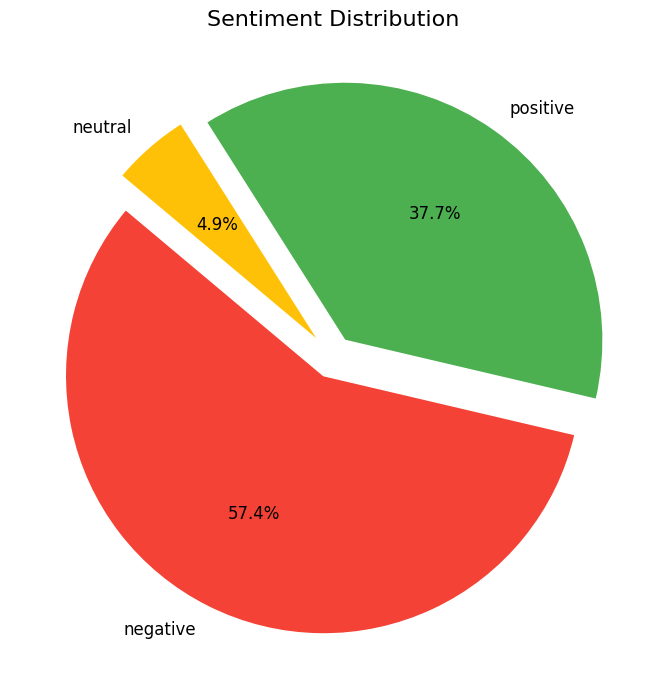

In [177]:
import matplotlib.pyplot as plt

# Hitung jumlah tiap label
sentiment_counts = clean_df['polarity'].value_counts()

# 🔥 Ambil label otomatis (biar sesuai data)
labels = sentiment_counts.index.tolist()
sizes = sentiment_counts.values

# 🔥 Warna sesuai label
color_map = {
    'positive': '#4CAF50',
    'neutral': '#FFC107',
    'negative': '#F44336'
}
colors = [color_map[label] for label in labels]

# 🔥 Semua slice dipisah biar rapi
explode = [0.08] * len(labels)

# Plot
plt.figure(figsize=(7,7))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white'}
)

plt.title('Sentiment Distribution', fontsize=16)
plt.tight_layout()
plt.show()

In [178]:
# Mengatur opsi tampilan Pandas agar kolom dapat menampilkan teks hingga 3000 karakter.
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame baru 'positive_tweets' yang hanya berisi tweet dengan polaritas positif.
positive_tweets = clean_df[clean_df['polarity'] == 'positive']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'positive_tweets'.
positive_tweets = positive_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]

# Mengurutkan DataFrame 'positive_tweets' berdasarkan 'polarity_score' secara menurun.
positive_tweets = positive_tweets.sort_values(by='polarity_score', ascending=False)

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
positive_tweets = positive_tweets.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
positive_tweets.index += 1

In [179]:
# Mengatur opsi tampilan Pandas agar kolom dapat menampilkan teks hingga 3000 karakter.
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame baru 'negative_tweets' yang hanya berisi tweet dengan polaritas negatif.
negative_tweets = clean_df[clean_df['polarity'] == 'negative']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'negative_tweets'.
negative_tweets = negative_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]

# Mengurutkan DataFrame 'negative_tweets' berdasarkan 'polarity_score' secara menaik (ascending).
negative_tweets = negative_tweets.sort_values(by='polarity_score', ascending=True)

# Memilih 10 baris pertama dari DataFrame yang sudah diurutkan.
negative_tweets = negative_tweets[0:10]

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
negative_tweets = negative_tweets.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
negative_tweets.index += 1

In [180]:
# Mengatur tampilan kolom
pd.set_option('display.max_colwidth', 3000)

# Ambil data neutral
neutral_tweets = clean_df[clean_df['polarity'] == 'neutral']

# Pilih kolom penting
neutral_tweets = neutral_tweets[['text_akhir', 'polarity_score', 'polarity', 'text_stopword']]

# Urutkan (biasanya netral itu score mendekati 0)
neutral_tweets = neutral_tweets.sort_values(by='polarity_score', ascending=False)

# Ambil beberapa contoh (biar tidak terlalu panjang)
neutral_tweets = neutral_tweets.head(10)

# Reset index
neutral_tweets = neutral_tweets.reset_index(drop=True)
neutral_tweets.index += 1


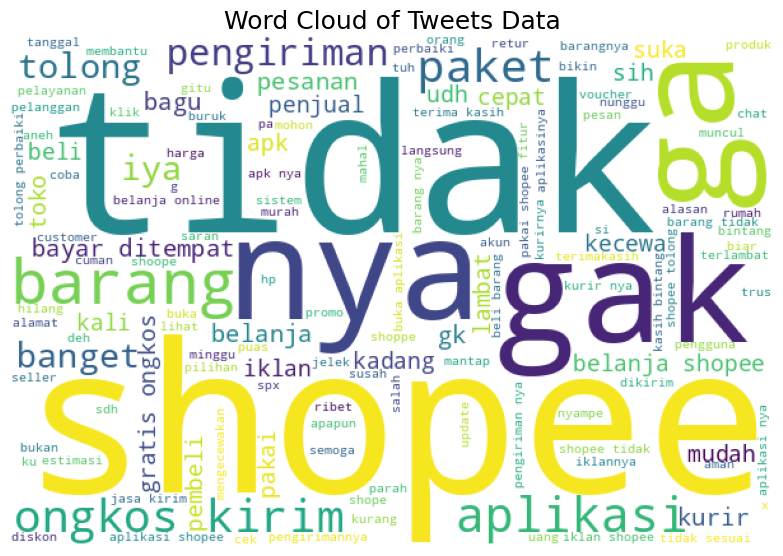

In [181]:
# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan.
list_words = ''

# Iterasi melalui setiap tweet dalam kolom 'text_stopword' dari DataFrame 'clean_df'.
for tweet in clean_df['text_stopword']:
    # Iterasi melalui setiap kata dalam tweet.
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Tweets Data', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

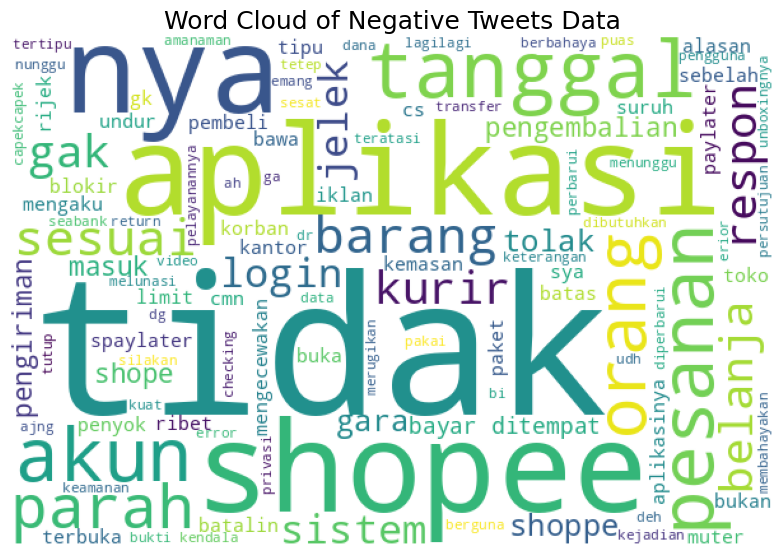

In [182]:
# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan dalam tweet negatif.
list_words = ''

# Iterasi melalui setiap tweet dalam kolom 'text_stopword' dari DataFrame 'negative_tweets'.
for tweet in negative_tweets['text_stopword']:
    # Iterasi melalui setiap kata dalam tweet.
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Negative Tweets Data', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

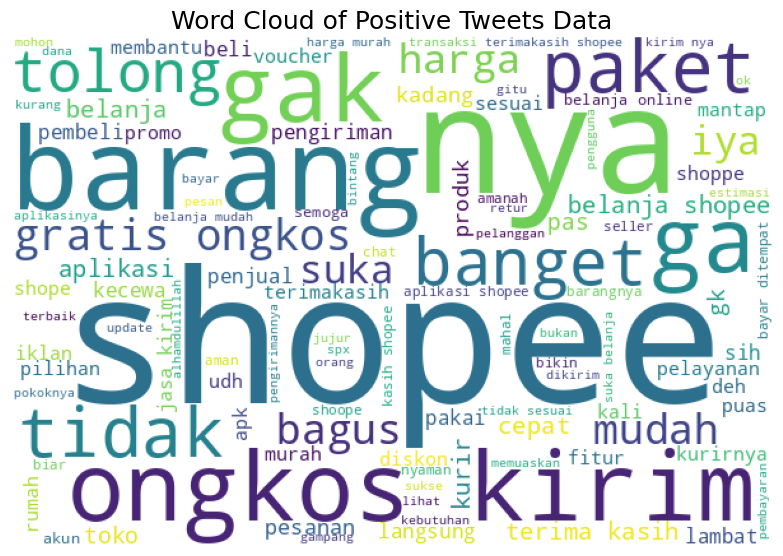

In [183]:
# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan dalam tweet positif.
list_words = ''

# Iterasi melalui setiap tweet dalam kolom 'text_stopword' dari DataFrame 'positive_tweets'.
for tweet in positive_tweets['text_stopword']:
    # Iterasi melalui setiap kata dalam tweet.
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Positive Tweets Data', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

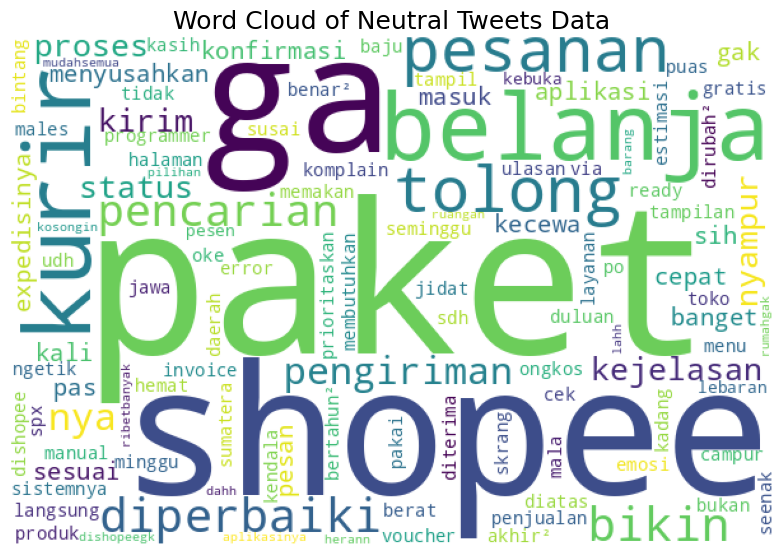

In [184]:
# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan dalam tweet neutral.
list_words = ''

# Iterasi melalui setiap tweet dalam kolom 'text_stopword' dari DataFrame 'neutral_tweets'.
for tweet in neutral_tweets['text_stopword']:
    # Iterasi melalui setiap kata dalam tweet.
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Neutral Tweets Data', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

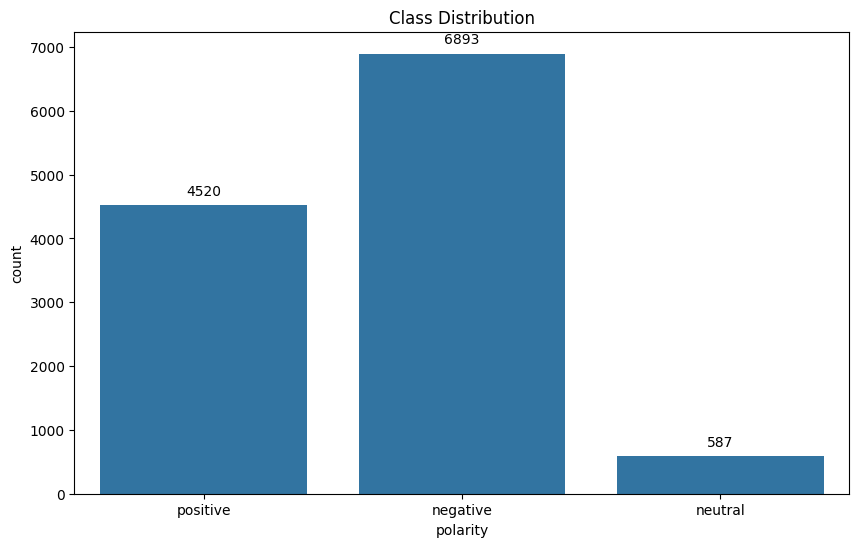

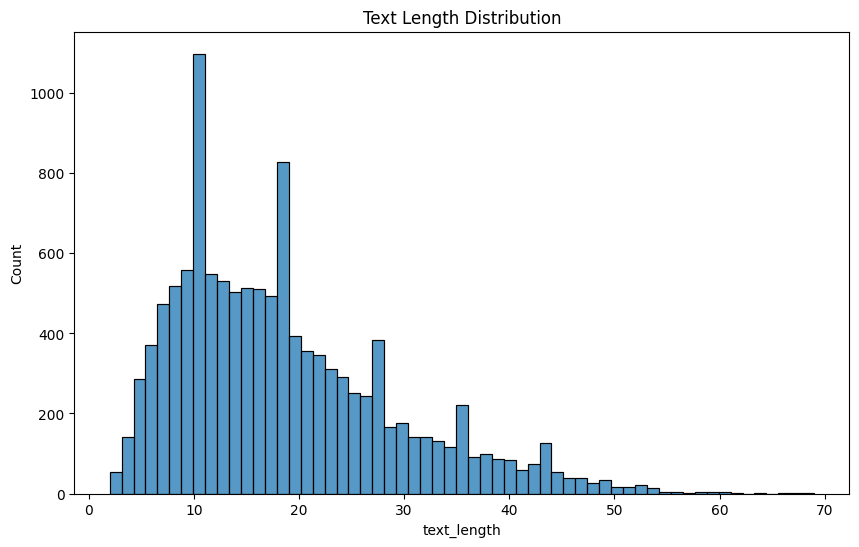

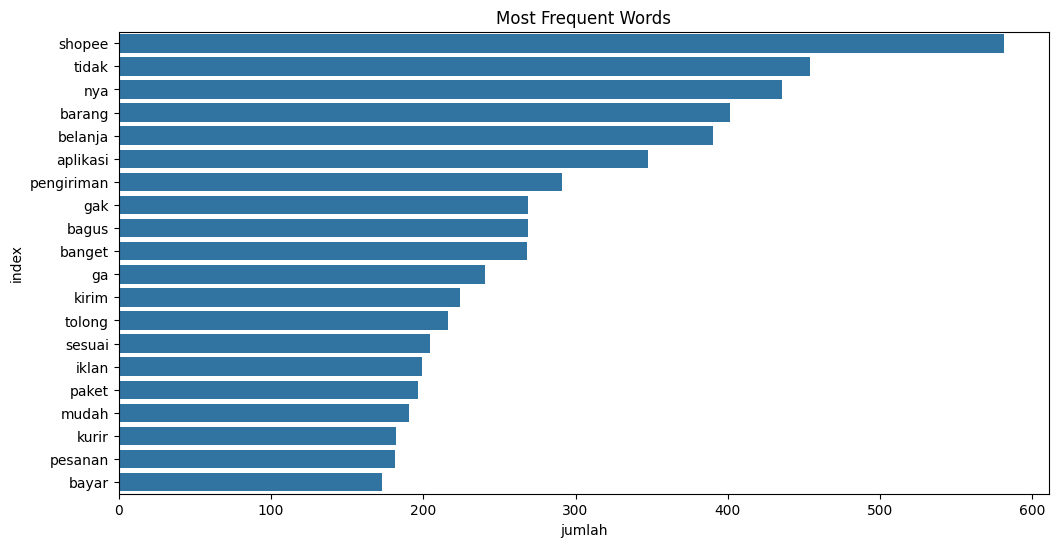

In [185]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# Set the figure size
plt.figure(figsize=(10, 6))

# Check class distribution
class_dist_plot = sns.countplot(x='polarity', data=clean_df)
plt.title('Class Distribution')

# Add counts above the bars on the plot
for p in class_dist_plot.patches:
    class_dist_plot.annotate(format(p.get_height(), '.0f'),
                              (p.get_x() + p.get_width() / 2., p.get_height()),
                              ha='center', va='center',
                              xytext=(0, 10),
                              textcoords='offset points')

plt.show()

# Set the figure size
plt.figure(figsize=(10, 6))

# Visualize text length distribution
clean_df['text_length'] = clean_df['text_akhir'].apply(lambda x: len(x.split()))
sns.histplot(clean_df['text_length'])
plt.title('Text Length Distribution')
plt.show()

# Set the figure size
plt.figure(figsize=(12, 6))

# Visualize most frequent words
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(clean_df['text_akhir'])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df = tfidf_df.sum().reset_index(name='jumlah')
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False).head(20)
sns.barplot(x='jumlah', y='index', data=tfidf_df)
plt.title('Most Frequent Words')
plt.show()

In [186]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score

Pada tahap ini dilakukan import library yang akan digunakan dalam proses pelatihan model machine learning, termasuk TF-IDF untuk ekstraksi fitur dan Naive Bayes sebagai baseline model.

## **Data Splitting**

## Data Splitting dan Ekstraksi Fitur

Pada tahap ini, data dibagi menjadi data latih dan data uji dengan rasio 80:20.
Metode stratified sampling digunakan untuk menjaga distribusi kelas tetap seimbang.

Selanjutnya dilakukan ekstraksi fitur menggunakan TF-IDF.
Proses fitting hanya dilakukan pada data latih untuk menghindari data leakage,
kemudian model digunakan untuk mentransformasi data uji.

In [187]:
clean_df.head(2)

,author,comment,rating,published_at,likes,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,polarity_score,polarity,text_length
0,misterius_,"Asli keamanannya bagus, aman juga lancar semua terkombinasi menjadi 1,performanya baik, bebas iklan, bug ataupun lemot, lancar jaya ketika dijalankan & membuka semua fitur2nya. Namun disayangkan sering ketika di pake terkadang agak"" susah membukanya pas saat koneksi lagi jelek / tidak stabil, terkadang loadingnya lambat sekali & cuma berputar aja.. mungkin cuman hal seperti itu yang biasa terjadi di apps ini dan aplikaainya sudah berjalan dengan baik, aplnya berfungsi sesuai keinginan -Adit baun",5,2026-03-03 12:39:10,5,Asli keamanannya bagus aman juga lancar semua terkombinasi menjadi performanya baik bebas iklan bug ataupun lemot lancar jaya ketika dijalankan membuka semua fiturnya Namun disayangkan sering ketika di pake terkadang agak susah membukanya pas saat koneksi lagi jelek tidak stabil terkadang loadingnya lambat sekali cuma berputar aja mungkin cuman hal seperti itu yang biasa terjadi di apps ini dan aplikaainya sudah berjalan dengan baik aplnya berfungsi sesuai keinginan Adit baun,asli keamanannya bagus aman juga lancar semua terkombinasi menjadi performanya baik bebas iklan bug ataupun lemot lancar jaya ketika dijalankan membuka semua fiturnya namun disayangkan sering ketika di pake terkadang agak susah membukanya pas saat koneksi lagi jelek tidak stabil terkadang loadingnya lambat sekali cuma berputar aja mungkin cuman hal seperti itu yang biasa terjadi di apps ini dan aplikaainya sudah berjalan dengan baik aplnya berfungsi sesuai keinginan adit baun,asli keamanannya bagus aman juga lancar semua terkombinasi menjadi performanya baik bebas iklan bug ataupun lambat lancar jaya ketika dijalankan membuka semua fiturnya namun disayangkan sering ketika di pakai terkadang agak susah membukanya pas saat koneksi lagi jelek tidak stabil terkadang loadingnya lambat sekali cuma berputar saja mungkin cuman hal seperti itu yang biasa terjadi di apps ini dan aplikaainya sudah berjalan dengan baik aplnya berfungsi sesuai keinginan adit baun,"[asli, keamanannya, bagus, aman, juga, lancar, semua, terkombinasi, menjadi, performanya, baik, bebas, iklan, bug, ataupun, lambat, lancar, jaya, ketika, dijalankan, membuka, semua, fiturnya, namun, disayangkan, sering, ketika, di, pakai, terkadang, agak, susah, membukanya, pas, saat, koneksi, lagi, jelek, tidak, stabil, terkadang, loadingnya, lambat, sekali, cuma, berputar, saja, mungkin, cuman, hal, seperti, itu, yang, biasa, terjadi, di, apps, ini, dan, aplikaainya, sudah, berjalan, dengan, baik, aplnya, berfungsi, sesuai, keinginan, adit, baun]","[asli, keamanannya, bagus, aman, lancar, terkombinasi, performanya, bebas, iklan, bug, lambat, lancar, jaya, dijalankan, membuka, fiturnya, disayangkan, pakai, terkadang, susah, membukanya, pas, koneksi, jelek, tidak, stabil, terkadang, loadingnya, lambat, berputar, cuman, apps, aplikaainya, berjalan, aplnya, berfungsi, sesuai, adit, baun]",asli keamanannya bagus aman lancar terkombinasi performanya bebas iklan bug lambat lancar jaya dijalankan membuka fiturnya disayangkan pakai terkadang susah membukanya pas koneksi jelek tidak stabil terkadang loadingnya lambat berputar cuman apps aplikaainya berjalan aplnya berfungsi sesuai adit baun,6,positive,39
1,Nailah Rahmaa,"Aplikasinya bagus, mudah dimengerti. Tapi bisa ga kalau bikin iklan di website/tempat lain tuh ga otomatis masuk ke aplikasinya? kek clickbait bgt bikin risih. Kalau mau bikin iklan tuh unjukin barang barang bagusnya bukan malah maksa user masuk ke aplikasi.",2,2026-03-16 01:12:19,1,Aplikasinya bagus mudah dimengerti Tapi bisa ga kalau bikin iklan di websitetempat lain tuh ga otomatis masuk ke aplikasinya kek clickbait bgt bikin risih Kalau mau bikin iklan tuh unjukin barang barang bagusnya bukan malah maksa user masuk ke aplikasi,aplikasinya bagus mudah dimengerti tapi bisa ga kalau bikin iklan di we

In [192]:
# ==============================
# DATA SPLITTING
# ==============================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ------------------------------
# 1. Pisahkan fitur (X) dan label (y)
# ------------------------------
X = clean_df['text_akhir']     # teks hasil preprocessing
y = clean_df['polarity']       # label sentimen

# ------------------------------
# 2. Encode label (text → angka)
# ------------------------------
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Contoh:
# positive → 2
# neutral  → 1
# negative → 0

# ==============================
# CLASS WEIGHT
# ==============================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Hitung bobot untuk setiap kelas
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_encoded),
    y=y_encoded
)

# Ubah ke bentuk dictionary (format yang dibutuhkan model)
class_weights_dict = dict(enumerate(class_weights))

# Tampilkan hasil
print("Class Weights:", class_weights_dict)

# ------------------------------
# 3. Split data (train & test)
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,
    stratify=y_encoded    # 🔥 penting: menjaga distribusi class
)

# ------------------------------
# 4. Cek hasil splitting
# ------------------------------
print("Jumlah data training:", len(X_train))
print("Jumlah data testing :", len(X_test))

Class Weights: {0: np.float64(0.5802988539097635), 1: np.float64(6.814310051107325), 2: np.float64(0.8849557522123894)}
Jumlah data training: 9600
Jumlah data testing : 2400


## **TFIDF**

In [193]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Inisialisasi TF-IDF Vectorizer
# max_features=200 → membatasi jumlah fitur (kata)
# min_df=17 → kata harus muncul minimal 17 dokumen
# max_df=0.8 → mengabaikan kata yang terlalu sering muncul

tfidf = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8)

# Fit hanya pada data training untuk menghindari data leakage
X_train_tfidf = tfidf.fit_transform(X_train)

In [194]:
# Mengubah data testing menggunakan TF-IDF yang sudah dilatih dari data training

X_test_tfidf = tfidf.transform(X_test)

In [195]:
import pandas as pd

# Mengubah hasil TF-IDF menjadi DataFrame agar lebih mudah dibaca
features_df = pd.DataFrame(
    X_train_tfidf.toarray(),
    columns=tfidf.get_feature_names_out()
)

# Menampilkan beberapa fitur teratas
features_df.head()

,admin,akun,alamat,alasan,aman,amanah,aneh,apapun,apk,aplikasi,...,tidak,toko,tolong,trus,tuh,uang,udh,update,video,voucher
0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
1,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
2,0.0,0.0,0.327378,0.331208,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.351275,0.0,0.0,0.0,0.0,0.0,0.000000
3,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.314158,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.545488
4,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000


## **Pemodelan Naive Bayes**

In [196]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, classification_report

# Inisialisasi model Naive Bayes
naive_bayes = BernoulliNB()

# Training model menggunakan data training (tidak perlu .toarray())
naive_bayes.fit(X_train_tfidf, y_train)

# Prediksi pada data training dan testing
y_pred_train_nb = naive_bayes.predict(X_train_tfidf)
y_pred_test_nb = naive_bayes.predict(X_test_tfidf)

# Evaluasi akurasi
accuracy_train_nb = accuracy_score(y_train, y_pred_train_nb)
accuracy_test_nb = accuracy_score(y_test, y_pred_test_nb)

# Menampilkan hasil akurasi
print("Naive Bayes")
print("Accuracy Train:", accuracy_train_nb)
print("Accuracy Test :", accuracy_test_nb)

# Menampilkan laporan klasifikasi (lebih lengkap)
print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test_nb))

Naive Bayes
Accuracy Train: 0.7414583333333333
Accuracy Test : 0.7441666666666666

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.77      0.84      0.80      1379
           1       0.00      0.00      0.00       117
           2       0.70      0.69      0.70       904

    accuracy                           0.74      2400
   macro avg       0.49      0.51      0.50      2400
weighted avg       0.71      0.74      0.72      2400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Model Naive Bayes digunakan sebagai baseline model.
Hasil menunjukkan bahwa model mampu mengenali kelas positif dan negatif dengan cukup baik,
namun mengalami kesulitan dalam mengklasifikasikan kelas netral karena jumlah datanya lebih sedikit.

Hal ini menunjukkan adanya ketidakseimbangan data (imbalanced dataset) yang mempengaruhi performa model.

## **Logistic Regression**

In [197]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Inisialisasi model Logistic Regression
# max_iter ditingkatkan agar konvergen
# class_weight='balanced' untuk mengatasi imbalance (neutral kecil)

logistic_regression = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

# Training model (tanpa .toarray())
logistic_regression.fit(X_train_tfidf, y_train)

# Prediksi
y_pred_train_lr = logistic_regression.predict(X_train_tfidf)
y_pred_test_lr = logistic_regression.predict(X_test_tfidf)

# Evaluasi akurasi
accuracy_train_lr = accuracy_score(y_train, y_pred_train_lr)
accuracy_test_lr = accuracy_score(y_test, y_pred_test_lr)

print("Logistic Regression")
print("Accuracy Train:", accuracy_train_lr)
print("Accuracy Test :", accuracy_test_lr)

# Evaluasi lengkap
print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test_lr))

Logistic Regression
Accuracy Train: 0.7365625
Accuracy Test : 0.7304166666666667

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1379
           1       0.12      0.48      0.19       117
           2       0.83      0.72      0.77       904

    accuracy                           0.73      2400
   macro avg       0.62      0.65      0.60      2400
weighted avg       0.84      0.73      0.78      2400



Meskipun akurasi Logistic Regression sedikit lebih rendah dibandingkan Naive Bayes, model ini mampu mengenali ketiga kelas sentimen, termasuk kelas netral yang sebelumnya tidak terdeteksi.

Hal ini menunjukkan bahwa Logistic Regression lebih baik dalam menangani multi-class classification dibandingkan Naive Bayes pada dataset ini.

## **LTSM**

In [202]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logistic_regression = LogisticRegression(max_iter=1000)

# Menggunakan data TF-IDF untuk melatih model Logistic Regression
logistic_regression.fit(X_train_tfidf, y_train)

# Melakukan prediksi pada data training dan testing menggunakan data TF-IDF
y_pred_train_lr = logistic_regression.predict(X_train_tfidf)
y_pred_test_lr = logistic_regression.predict(X_test_tfidf)

accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)
accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)

print('Logistic Regression - accuracy_train:', accuracy_train_lr)
print('Logistic Regression - accuracy_test:', accuracy_test_lr)

Logistic Regression - accuracy_train: 0.8338541666666667
Logistic Regression - accuracy_test: 0.8304166666666667
